[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/zhimingkuang/Harvard-AM-115/blob/main/12_earth_age/heat_equation_for_student.ipynb)

# Lord Kelvin Workshop

by Kaylee Vo

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import scipy.sparse as sparse
import IPython.display as IP

## Problem 1

### Part A

You should start by considering the domain over which you will solve the equation and the boundary conditions. One domain choice is $0<x<L$, where L is large enough (deep enough inside Earth) so that temperature is not changing significantly (which needs to be checked after the solution is obtained). What should the initial and boundary conditions be? Note that your computational domain shouldn’t include the surface, as the temperature at the surface is known at all times. Instead, your computational domain should start one grid point below the surface. This is what is assumed in the code that is provided to you as a starting point (see part b).

--


In [74]:
# radius_earth = 6370  # km
# km one sixth of the radius of the Earth
# to make run time quicker
radius_earth = 1000

- Initially, we set the radius of the earth ($L$) to be 6370 km, but this made runtime too long. We'll set the L to be 1000 km instead, which is one sixth the radius of the Earth.
- We use the line `x = np.linspace(dx, m * dx, num=m, endpoint=True)` because we start at dx, one grid point below the surface.
- We'll define the boundary conditions in matrix $A$ and vector $b$ in Part D.


### Part B

Decide how many grid points to use to represent your domain and solve the problem numerically (you can use the code heat_equation_for_student.m as a starting point).

--

In [112]:
# Define grid spacing in km
dx = 1
# Define the number of grid points
m = radius_earth // dx

# Define the grid
# We start at dx because we want to the computational domain
# to start one grid point below the surface
x = np.linspace(dx, m * dx, num=m, endpoint=True)

# Integration time
# Let time be in units of million of years
time_e = 100

# Initial condition
# uniform at 2000 degrees Celsius
y0 = np.ones(m) * 2000

The equation we have is 
$$
\frac{\partial y}{\partial t} = D \frac{\partial^2 y}{\partial x^2}.
$$

The units for each variable are:
- $x$ is the distance to the center of the Earth, in km.
- $y$ is the temperature at that distance, in degrees Celsius.
- $t$ is in time, in million years.


In [113]:
print(f"The total number of grid points is {m} for dx={dx} km.")

The total number of grid points is 1000 for dx=1 km.


### Part C

Pay special attention to making the numerical values and the units of space, time, and diffusivity consistent. 

--

Now we convert $D$ to be in units of $\frac{km^2}{\text{million years}}$. This is to match the units of $x$ and $t$.

In [114]:
# thermal diffusivity of rocks is 1.2e-6 m^2/s
D = 1.2e-6 / 1e6  # convert to km^2/second
D = D * (60 * 60 * 24 * 365.25)  # convert to km^2/year
D = D * 1e6  # convert to km^2/million years

In [115]:
print(f"The thermal diffusivity constant is {round(D, 4)} km^2/million years.")

The thermal diffusivity constant is 37.8691 km^2/million years.


### Part D

Find the time when the temperature gradient drops below 25°C per kilometer. That’s the age of Earth determined by Kelvin. 

--

In [116]:
# Define the Laplacian operator
e1 = np.ones((1, m))  # build a vector of ones
diags = np.concatenate((e1, -2.0 * e1, e1))  # diagonal entries
offsets = np.array([-1, 0, 1])  # which diagonals

A = sparse.dia_matrix((diags, offsets), shape=(m, m))  # diagonal matrix
# Convert to format to make edits to the boundary conditions
# Will convert back
A = A.tolil()
A[-1, -1] = -1
A = A.tocsr()

In [117]:
# print the first 5 rows and columns
A.toarray()[:5, :5]

array([[-2.,  1.,  0.,  0.,  0.],
       [ 1., -2.,  1.,  0.,  0.],
       [ 0.,  1., -2.,  1.,  0.],
       [ 0.,  0.,  1., -2.,  1.],
       [ 0.,  0.,  0.,  1., -2.]])

In [118]:
# print the first 5 rows and columns
A.toarray()[-5:, -5:]

array([[-2.,  1.,  0.,  0.,  0.],
       [ 1., -2.,  1.,  0.,  0.],
       [ 0.,  1., -2.,  1.,  0.],
       [ 0.,  0.,  1., -2.,  1.],
       [ 0.,  0.,  0.,  1., -1.]])

In [119]:
b = np.zeros(m)
b[0] = 0.0  # Surface

- For the first row of $A$, we set the first element of $b$ to be 0, the surface temperature of the Earth. This boundary should be non-insulating, meaning the temperature gradient should be changing with time.
- Next, we change the last row of $A$ to be 1, -1. This is to enforce an insulating boundary condition at the center of the Earth. The temperature gradient should not be changing with time at the center of the Earth, as shown by the equation below:

$$
F_m = y_{m-1} - y_m = 0 \rightarrow y_m = y_{m-1}.
$$
- For the last grid point, the temperature gradient is 0 since $y_m = y_{m-1}$.


In [ ]:
# Use ode solvers for this; method of lines
def F(t, y, D, A, b, dx):
    """RHS of the heat equation

    Args:
        t (float): 1-D independent variable (time)
        y (numpy.ndarray): N-D vector-valued function (state)
        D (float): diffusivity
        A (numpy.ndarray): Laplacian operator
        b (numpy.ndarray): source term
        dx (float): grid spacing

    Returns:
        numpy.ndarray: differential equation

    """
    return D * (sparse.csr_matrix.dot(A, y) + b) / (dx**2)


time_steps = 500
sol = solve_ivp(
    F,
    [0, time_e],
    y0,
    args=(D, A, b, dx),
    max_step=1.0,
    dense_output=True,
    method="Radau",  # Runge-Kutta method
    t_eval=np.linspace(0, time_e, time_steps),  # evaluate at these
    options={"atol": 1e-6, "rtol": 1e-6},  # set tolerances for the solver
)
t = sol.t
y = sol.y

In [125]:
# Customize for matplotlib
# If interested in the matplotlib object hierarchy, check: https://realpython.com/python-matplotlib-guide/
plt.rcParams["axes.linewidth"] = 1
plt.rcParams["xtick.bottom"] = True
plt.rcParams["ytick.left"] = True
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rcParams["mathtext.default"] = "regular"
# Change font size: http://www.futurile.net/2016/02/27/matplotlib-beautiful-plots-with-style/
plt.rcParams["font.size"] = 12
plt.rcParams["axes.labelsize"] = 14
plt.rcParams["axes.labelweight"] = "bold"
plt.rcParams["xtick.labelsize"] = 12
plt.rcParams["ytick.labelsize"] = 12
plt.rcParams["legend.fontsize"] = 14
plt.rcParams["figure.titlesize"] = 20

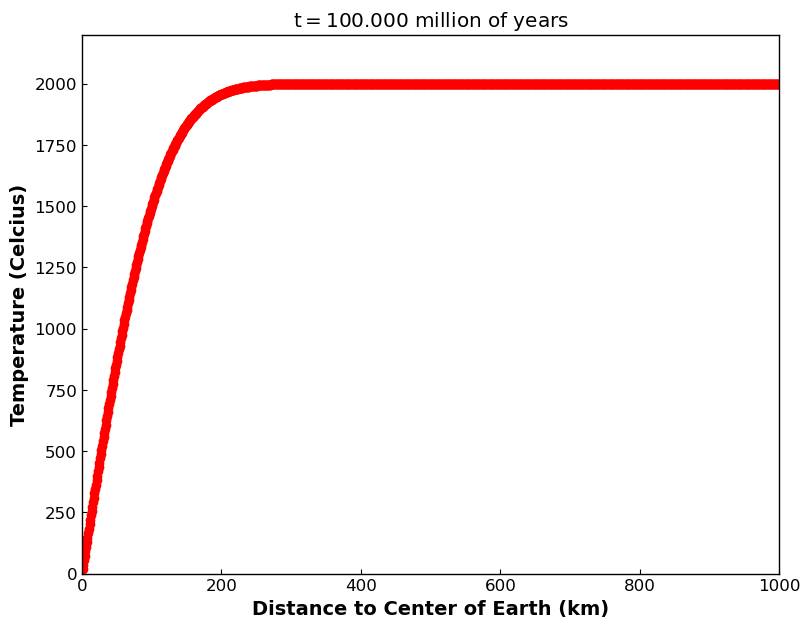

In [126]:
# Can comment out to run faster
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(1, 1, 1)

for i, time in enumerate(t):
    ax.cla()
    ax.plot(x, y[:, i], "r-o")
    ax.set_xlim(0, radius_earth)
    ax.set_ylim(0, 2200)
    ax.set_xlabel(r"Distance to Center of Earth (km)")
    ax.set_ylabel(r"Temperature (Celcius)")
    ax.set_title(r"$t = %.3f$ million of years" % time)

    IP.display(fig)
    IP.clear_output(wait=True)
    plt.pause(0.01)

In [127]:
threshold = 25  # °C/km

for t, y_t in enumerate(sol.t):

    gradient = (y[:, t][0] - 0) / dx

    if gradient <= threshold:
        print(round(y_t, 2), "million years")
        break

53.91 million years


- For this notebook we use Run 4 default values. We get an approximation of 53.91 million years for the age of the Earth.

### Part E

Change the number of grid points that you use to see if your answer changes (i.e. check numerical convergence).

--


|       | dx | time_steps | age |
|-------|----|------------|-----|
| Run 1 | 50 | 100 | 42.42 |
| Run 2 | 25 | 100 | 52.53 |
| Run 3 | 5  | 100 | 54.55 |
| Run 4 | 1  | 500 | 53.91 |

- From the different run results, the numerical approximation converges to the analytical solution of 53.47 million years (shown in Problem 2).
- As we increase the number of grid points and time steps, the approximation becomes more accurate. Run 1 is the coarsest, while Run 4 is the most refined.

### Part F

Is the one-dimension approximation of the sphere reasonable?

--

- The 1D approximation is reasonable if the temperature varies primarily with depth and not with latitude or longitude.
- It is not reasonable given that the Earth is a sphere and is not a flat surface.
- However, if most of the gradient change is near the surface, then it is reasonable to model the Earth's thermal changes in 1D.

## Problem 2

Check the solution using the analytical solution that we shall present in class (also on Canvas, see “Analytical solution to the Age of Earth problem.pdf”). Note that the numerical solution, while approximate, is more versatile. 

-- 

The analytical solution given in lecture is:

$$
u(x, t) = \frac{y_0 - y_s}{\sqrt{\pi D t}} e^{-\frac{x^2}{4Dt}}.
$$
- $u(x, t)$ is the temperature gradient.

We plug this into a Python function.


In [131]:
def analytical_solution(x, time_e, D):

    y0 = 2000
    ys = 0
    # This is the change of temperature for a single time step
    soln = (y0 - ys) / np.sqrt(np.pi * D * time_e) * np.exp(-(x**2) / (4 * D * time_e))

    return soln


# Not the most elegant but we loop over time steps
# and return the first time step that is less than the threshold

for t in np.arange(1, 100, 0.01):
    temp_gradient = analytical_solution(x, t, D)[0]
    if temp_gradient < threshold:
        t = round(t, 2)
        temp_gradient = round(temp_gradient, 2)
        print(f"Temp change = {temp_gradient} °C/km")
        print(f"Age of Earth: {t} million years")
        break

Temp change = 25.0 °C/km
Age of Earth: 53.79 million years


The analytical solution is 53.79 million years, which is close to the numerical solution of 53.91 million years from Run 4 (Part D).